In [1]:
# %% [Célula 1] Imports e Configurações
import os
import glob
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from typing import List, Dict, Optional, Tuple, Sequence

# Configurações de avisos e estilo
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

# Configuração global do Matplotlib (mantendo o estilo original)
plt.rcParams.update({
    'font.size': 25,
    'axes.labelsize': 27,
    'legend.fontsize': 15,
    'xtick.labelsize': 22,
    'ytick.labelsize': 22,
    'axes.titlesize': 27,
    'hatch.linewidth': 0.5
})

In [2]:
# %% [Célula 2] Configurações e Constantes

# Diretório base dos resultados
RESULTS_DIR = '../../results/results_flows*/*'

# Métricas que serão lidas ou calculadas
METRICAS_COLETA = [
    'tempo', 'cpu_utilization', 'gpu_utilization', 'cache_utilization',
    'bandwidth_utilization', 'bandwidth_utilization_per_flow',
    'success', 'latency', 'decision_time_ms', 'running_sfcs',
    'cpu_saved', 'shared_vnfs', 'shared_vnfs_per_flow',
    'cpu_per_flow', 'gpu_per_flow', 'cache_per_flow',
    "total_energy_consumption", "energy_consumption_per_flow",
    "jain_fairness_latencia_por_sessao", "acceptance_rate",
    "queue_time", "jain_cpu", "jain_gpu", "jain_bw", "avg_sfc_reliability"
]

# Mapeamento: Nome na Pasta -> Nome no Gráfico
NOME_ALGORITMOS_MAP = {
    'g': 'Greedy',
    'ga': 'OSCIM',
    'msf': 'MSF',
    'goku': 'OSCIM',
    'vegeta': 'Resilient-OSCIM',
    'musfico': 'MuSFiCO',
    'greedyb': 'GreedyB',
    'kuririnPPO': 'INOMMUS',
    'kuririnMaskablePPO': 'INOMMUS',
    'darsppo': 'DARSPPO',
    'darsppoMaskablePPO': 'DA-RSPPO',
    'hephaestus': 'hephaestus',
    'hephaestusMaskablePPO': 'Hephaestus'
}

# Cores específicas para cada algoritmo (Consistência visual)
CORES_ALGORITMOS = {
    "INOMMUS": "#1f77b4",     # Azul
    "DA-RSPPO": "#ff7f0e",    # Laranja
    "Hephaestus": "#2ca02c",  # Verde
    "OSCIM": "#d62728",       # Vermelho
    "GreedyB": "#9467bd",     # Roxo
    "Greedy": "#8c564b"       # Marrom
}

# Padrões de hachura (textura das barras)
HATCH_PATTERNS = ['//', '\\\\', '||', '--', '++', 'xx', 'oo', 'OO', '..', '**']

In [3]:
# %% [Célula 3] Funções de Processamento de Dados

def jain_fairness_index(x):
    """Calcula o índice de justiça de Jain para uma série."""
    x = x.dropna()
    n = len(x)
    if n == 0: return np.nan
    sum_sq = (x * x).sum()
    if sum_sq == 0: return 1.0
    return (x.sum() ** 2) / (n * sum_sq)

def enriquecer_dataframe(df):
    """Adiciona colunas calculadas ao DataFrame."""
    df = df.copy()

    # 1. Jain Fairness por Sessão
    if 'sfc_id' in df.columns and 'latency' in df.columns:
        df['session_id'] = df['sfc_id'].str.split('_').str[-1]
        df['jain_fairness_latencia_por_sessao'] = df.groupby('session_id')['latency'].transform(jain_fairness_index)
        df['jain_fairness_latencia_por_sessao'] = df['jain_fairness_latencia_por_sessao'].fillna(0)
        df.drop(columns=['session_id'], inplace=True)

    # 2. Métricas "Por Fluxo" (Divisão segura por running_sfcs)
    for metric, new_col in [
        ('total_energy_consumption', 'energy_consumption_per_flow'),
        ('bandwidth_utilization', 'bandwidth_utilization_per_flow'),
        ('shared_vnfs', 'shared_vnfs_per_flow')
    ]:
        if metric in df.columns:
            df[new_col] = np.where(df['running_sfcs'] == 0, 0.0, df[metric] / df['running_sfcs'])

    # 3. QoS Score
    if 'latency' in df.columns and 'success' in df.columns:
        df['pontuacao_latencia'] = df['latency'].apply(lambda x: 0 if pd.isna(x) else (-1 if x > 6 else 2))
        df['pontuacao_success'] = df['success'] * 10
        df['QoS'] = df['pontuacao_latencia'] + df['pontuacao_success']
    
    return df

In [4]:
# %% [Célula 4] Coleta de Dados

def coletar_dados(diretorio_pattern):
    data_frames = []
    diretorios = glob.glob(diretorio_pattern)
    
    print(f"Encontrados {len(diretorios)} diretórios de simulação.")

    for alg_dir in diretorios:
        # Extrair nome do algoritmo do caminho
        dir_name = os.path.basename(os.path.normpath(alg_dir))
        raw_name = dir_name.split('_')[0]
        # Tratamento para caminhos Windows/Linux misturados
        if '\\' in raw_name: raw_name = raw_name.split('\\')[-1]
        
        alg_name = NOME_ALGORITMOS_MAP.get(raw_name, raw_name)
        
        files = glob.glob(os.path.join(alg_dir, "*.csv"))
        # print(f"Lendo {alg_name}: {len(files)} arquivos.")

        for file in files:
            try:
                df = pd.read_csv(file)
                
                # Ajustes iniciais e Filtros
                df = enriquecer_dataframe(df)
                
                # Calcular tempo relativo (segundos desde o início)
                start_time = df['timestamp'].values[0]
                df['tempo'] = (df['timestamp'] - start_time).astype(int)
                
                # Verificar se a simulação foi válida (> 100s)
                if df['tempo'].max() < 100:
                    continue

                # Sucesso acumulativo (média expandida)
                df['success'] = df['success'].expanding().mean()

                # Agrupamento temporal (segundo a segundo) e preenchimento (ffill)
                df_grouped = df.groupby('tempo', as_index=False).mean(numeric_only=True)
                max_time = df_grouped['tempo'].max()
                
                # Reindexar para garantir continuidade temporal
                idx_completo = pd.RangeIndex(start=0, stop=max_time + 1, name='tempo')
                df_final = df_grouped.set_index('tempo').reindex(idx_completo).fillna(method='ffill').reset_index()
                
                # Recorte de 1000 segundos (padrão do paper)
                df_final = df_final.iloc[0:1000]
                df_final['algorithm'] = alg_name
                
                data_frames.append(df_final)

            except Exception as e:
                print(f"Erro ao ler {file}: {e}")
                continue

    if data_frames:
        big_df = pd.concat(data_frames, ignore_index=True)
        # Normalizações globais finais (/100)
        cols_to_normalize = ['acceptance_rate', 'cpu_per_flow', 'gpu_per_flow', 'cache_per_flow']
        for col in cols_to_normalize:
            if col in big_df.columns:
                big_df[col] = big_df[col] / 100
        return big_df
    else:
        return pd.DataFrame()

In [5]:
# %% [Célula 5] Executar Carregamento

print("Iniciando coleta...")
big_data = coletar_dados(RESULTS_DIR)

# Filtro final: Remover período de aquecimento (< 200s)
if not big_data.empty:
    print(f"Total de linhas carregadas: {len(big_data)}")
    big_data = big_data[big_data['tempo'] >= 0].copy()
    print(f"Linhas após filtro de aquecimento (>= 200s): {len(big_data)}")
else:
    print("Nenhum dado encontrado! Verifique o caminho RESULTS_DIR.")

Iniciando coleta...
Encontrados 3 diretórios de simulação.
Total de linhas carregadas: 14533
Linhas após filtro de aquecimento (>= 200s): 14533


In [6]:
# %% [Célula 6] Funções de Plotagem

def create_boxplot(df, y_col, title, filename=None, show_outliers=False, steps=200):
    """
    Cria boxplot temporal agrupado por janelas de tempo.
    """
    # Preparar dados
    df_plot = df.copy()
    df_plot['window'] = (df_plot['tempo'] // steps + 1) * steps
    
    # Ordenação e Labels
    windows = sorted(df_plot['window'].unique())
    algs = sorted(df_plot['algorithm'].unique(), key=lambda x: list(CORES_ALGORITMOS.keys()).index(x) if x in CORES_ALGORITMOS else 999)
    
    # Configurar Figura
    fig, ax = plt.subplots(figsize=(9.8, 6.2)) # Aproximadamente 950x600px
    
    group_width = 0.8
    box_width = group_width / len(algs)
    positions_base = np.arange(len(windows))
    
    legend_handles = []

    for i, alg in enumerate(algs):
        color = CORES_ALGORITMOS.get(alg, plt.cm.tab10(i))
        hatch = HATCH_PATTERNS[i % len(HATCH_PATTERNS)]
        
        # Filtrar dados do algoritmo
        alg_data = df_plot[df_plot['algorithm'] == alg]
        
        # Dados por janela
        data_per_window = []
        for w in windows:
            vals = alg_data[alg_data['window'] == w][y_col].dropna().values
            data_per_window.append(vals)
            
        # Posição deslocada para agrupar
        offset = (i - len(algs)/2) * box_width + box_width/2
        positions = positions_base + offset
        
        # Estilo dos Outliers
        flier_props = dict(marker='o', markersize=3, markerfacecolor=color, markeredgecolor=color, alpha=0.7)
        
        # Desenhar Boxplot
        bp = ax.boxplot(data_per_window, positions=positions, widths=box_width*0.9,
                        patch_artist=True, showfliers=show_outliers,
                        boxprops=dict(facecolor=color, hatch=hatch, alpha=0.5, linewidth=1.2),
                        medianprops=dict(color='black', linewidth=1.8),
                        flierprops=flier_props if show_outliers else dict(marker=''))

        # Reforçar cores e hatch
        for patch in bp['boxes']:
            patch.set_facecolor(color)
            patch.set_hatch(hatch)
            patch.set_edgecolor('black')

        legend_handles.append(Patch(facecolor=color, edgecolor='black', hatch=hatch, alpha=0.5, label=alg))

    # Formatação do Eixo
    ax.set_ylabel(title, labelpad=10)
    ax.set_xticks(positions_base)
    ax.set_xticklabels([]) # Remove labels do eixo X conforme solicitado
    ax.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
    ax.grid(axis='y', linestyle='--', alpha=0.5, linewidth=0.8)

    # Legenda
    ax.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 1.15),
              ncol=min(4, len(algs)), frameon=False, handlelength=2.2)

    plt.tight_layout()
    
    if filename:
        plt.savefig(filename, dpi=300)
        print(f"Salvo: {filename}")
    plt.show()

def create_binned_boxplot(df, x_col, y_col, x_label, y_label, bin_size=10, filename=None):
    """
    Cria boxplot agrupado por bins de uma métrica X.
    """
    df_plot = df.copy()
    
    # Criar Bins
    # Multiplica por 100 assumindo que x_col está normalizado (0-1), ajuste se necessário
    df_plot['x_scaled'] = df_plot[x_col] * 100
    df_plot['bin'] = (np.ceil(df_plot['x_scaled'] / bin_size) * bin_size).astype(int)
    
    bins = sorted(df_plot['bin'].unique())
    algs = sorted(df_plot['algorithm'].unique()) # Ou ordem customizada
    
    fig, ax = plt.subplots(figsize=(9.8, 6.2))
    
    box_width = 0.8 / len(algs)
    positions_base = np.arange(len(bins))
    legend_handles = []

    for i, alg in enumerate(algs):
        color = CORES_ALGORITMOS.get(alg, plt.cm.tab10(i))
        hatch = HATCH_PATTERNS[i % len(HATCH_PATTERNS)]
        
        alg_data = df_plot[df_plot['algorithm'] == alg]
        data_per_bin = [alg_data[alg_data['bin'] == b][y_col].dropna().values for b in bins]
        
        offset = (i - len(algs)/2) * box_width + box_width/2
        bp = ax.boxplot(data_per_bin, positions=positions_base + offset, widths=box_width*0.9,
                        patch_artist=True, showfliers=True,
                        boxprops=dict(facecolor=color, hatch=hatch, alpha=0.5),
                        medianprops=dict(color='black'),
                        flierprops=dict(marker='o', markersize=3, markerfacecolor=color, alpha=0.7))
        
        for patch in bp['boxes']:
            patch.set_facecolor(color)
            patch.set_hatch(hatch)
            
        legend_handles.append(Patch(facecolor=color, hatch=hatch, alpha=0.5, label=alg))

    ax.set_ylabel(y_label)
    ax.set_xlabel(x_label)
    ax.set_xticks(positions_base)
    ax.set_xticklabels([str(b) for b in bins])
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    ax.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 1.15),
              ncol=min(4, len(algs)), frameon=True)
    
    plt.tight_layout()
    if filename: plt.savefig(filename, dpi=300)
    plt.show()

Salvo: boxplot_Latency_ms__clean.pdf


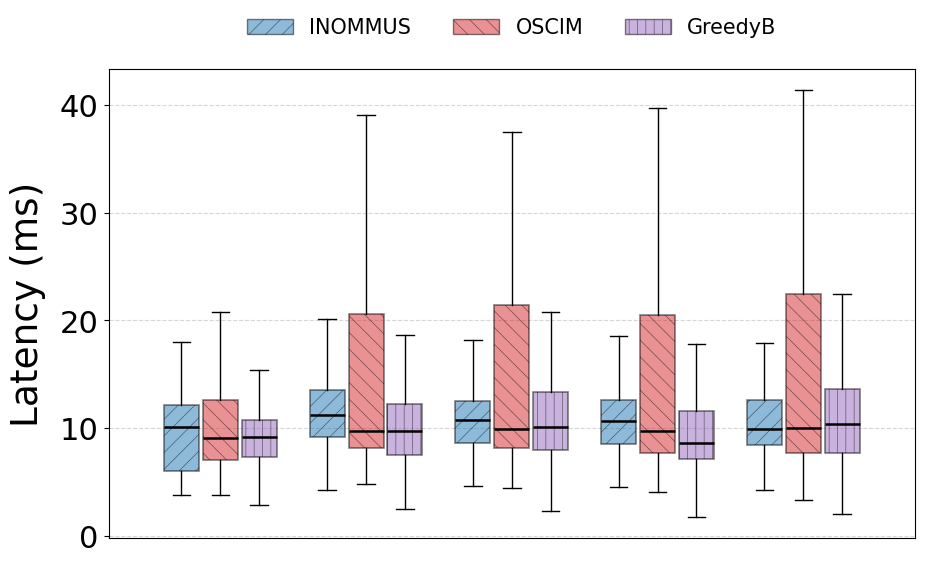

Salvo: boxplot_Latency_ms__outliers.pdf


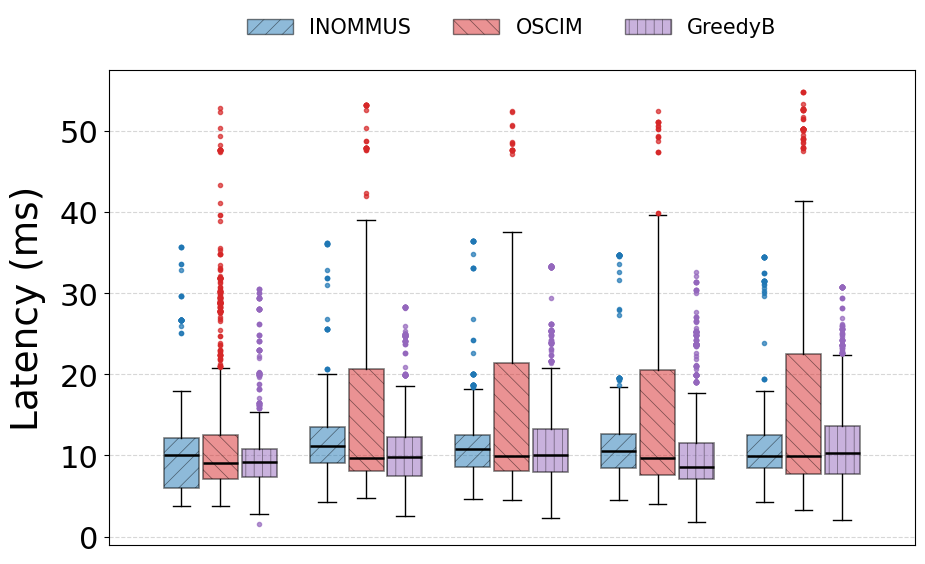

Salvo: boxplot_Acceptance_Ratio__clean.pdf


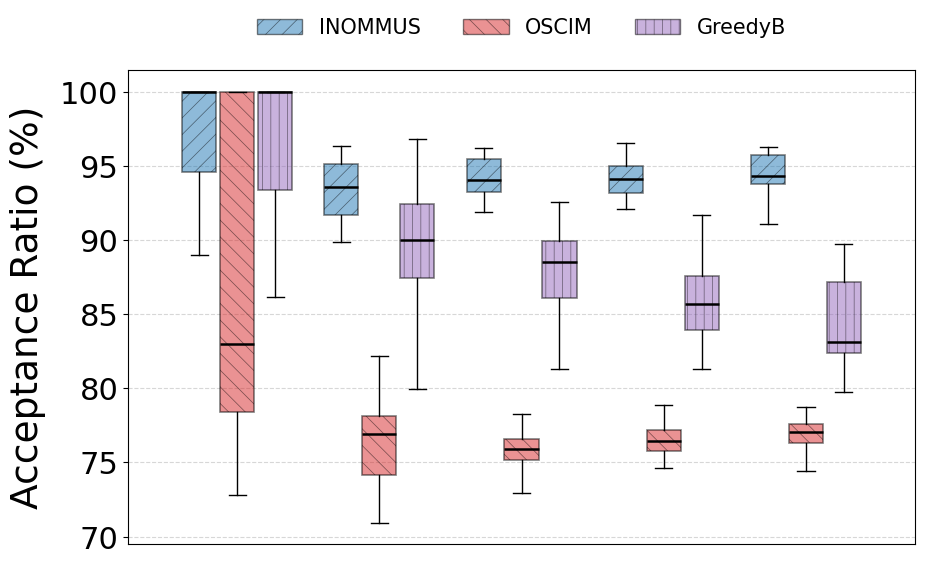

Salvo: boxplot_Acceptance_Ratio__outliers.pdf


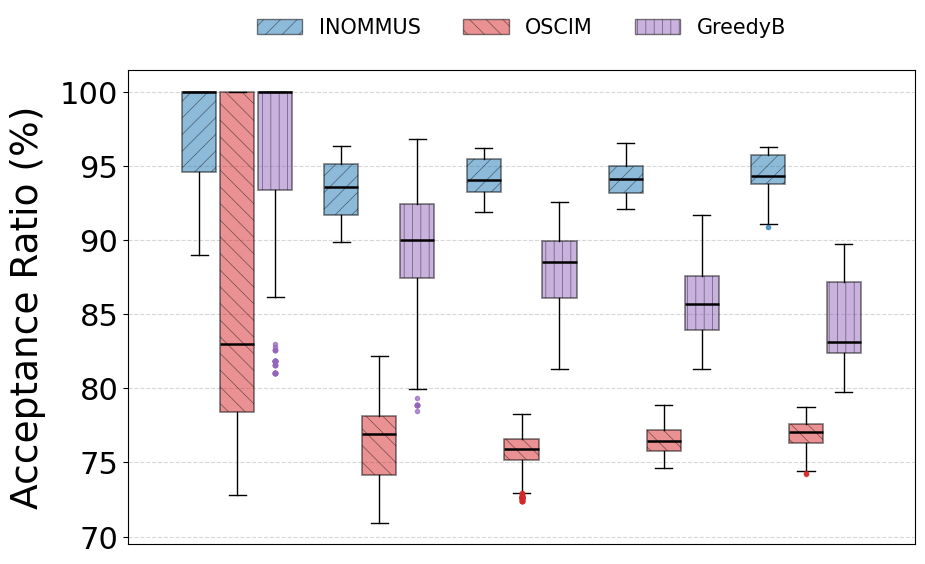

Salvo: boxplot_Decision_Time_ms__clean.pdf


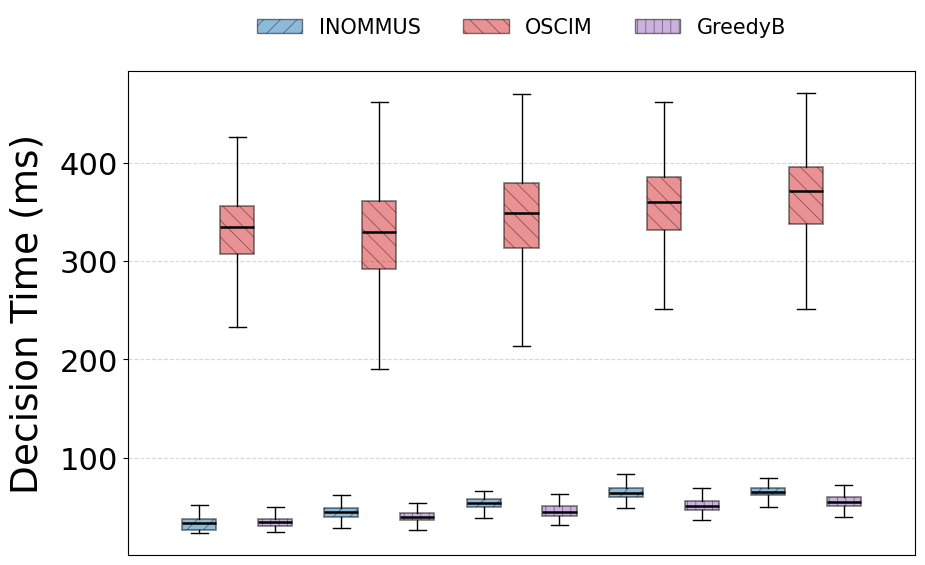

Salvo: boxplot_Decision_Time_ms__outliers.pdf


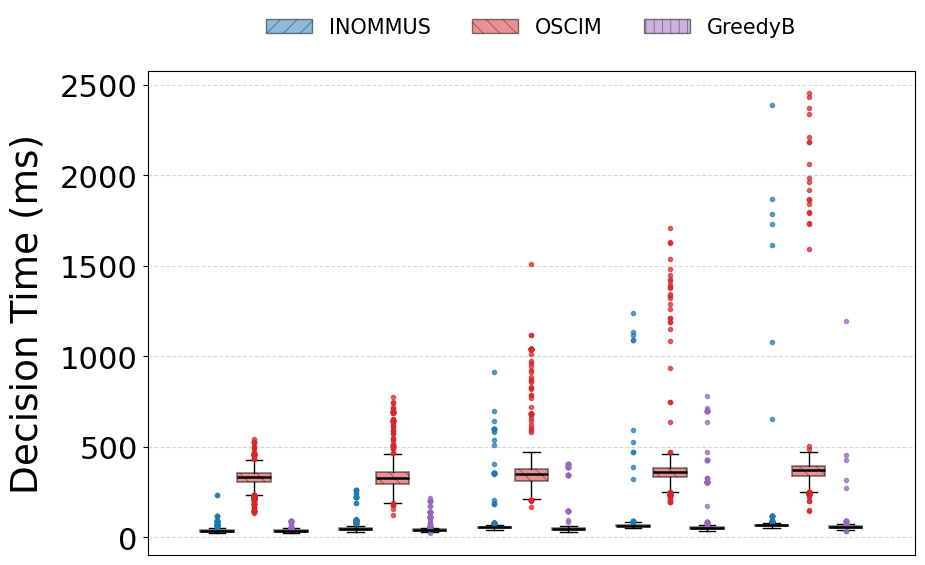

Salvo: boxplot_CPU_Util_per_Flow__clean.pdf


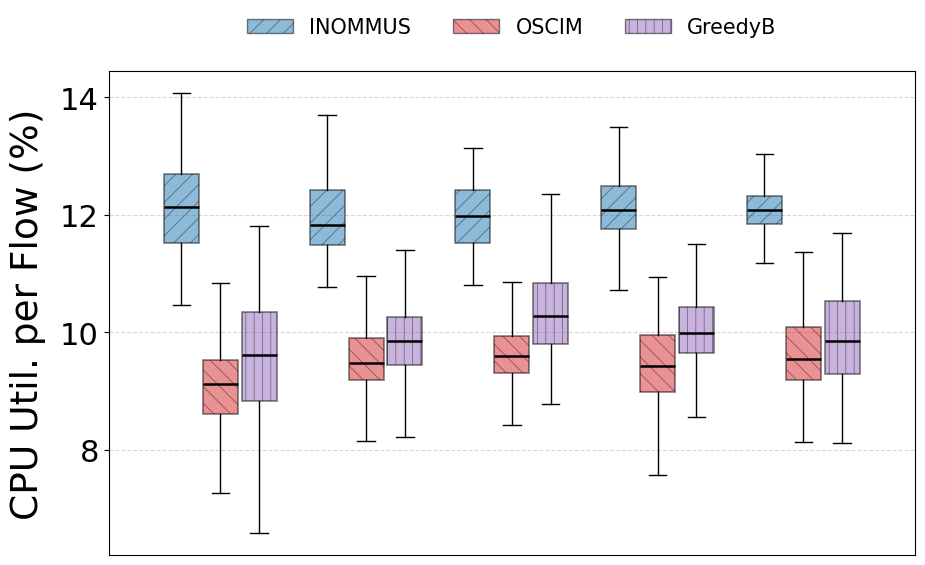

Salvo: boxplot_CPU_Util_per_Flow__outliers.pdf


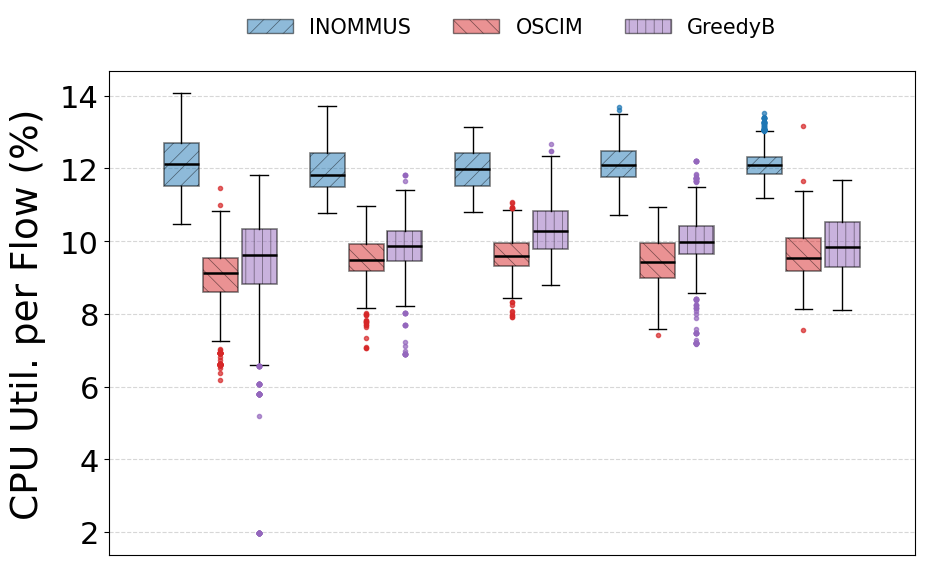

Salvo: boxplot_GPU_Util_per_Flow__clean.pdf


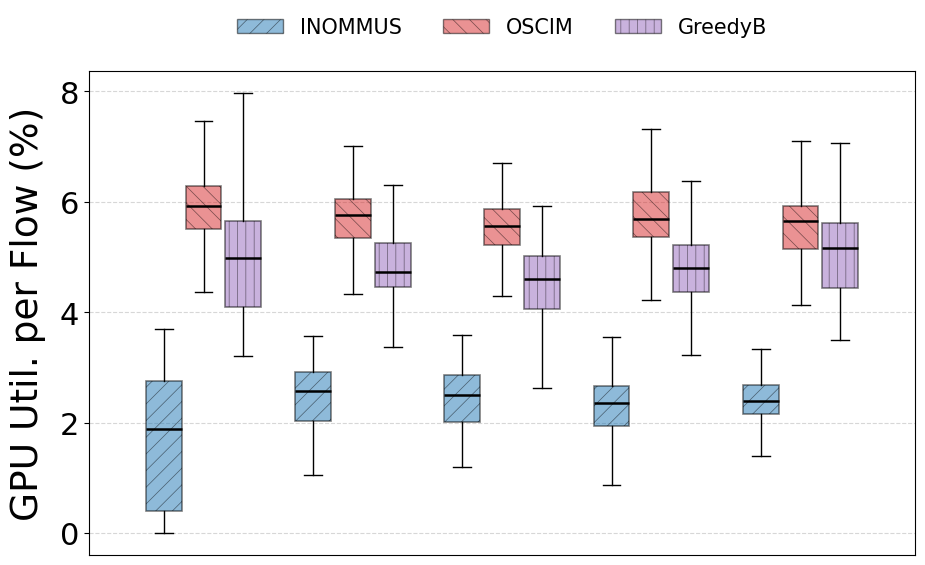

Salvo: boxplot_GPU_Util_per_Flow__outliers.pdf


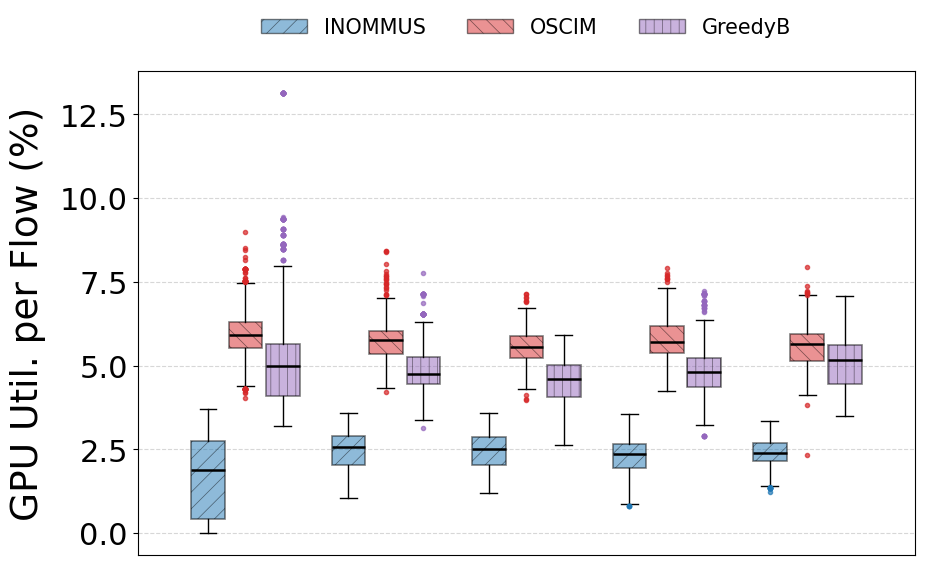

Salvo: boxplot_Band_Util_per_Flow__clean.pdf


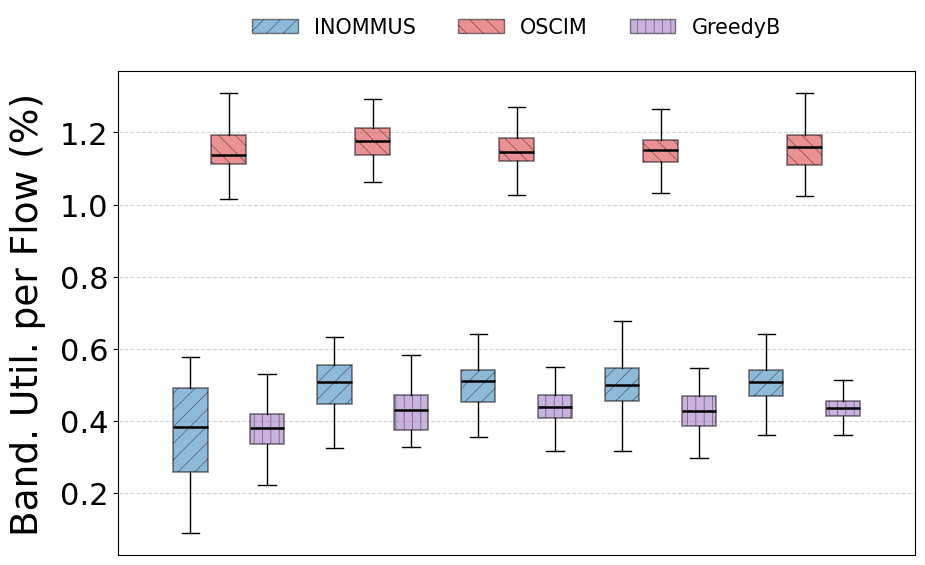

Salvo: boxplot_Band_Util_per_Flow__outliers.pdf


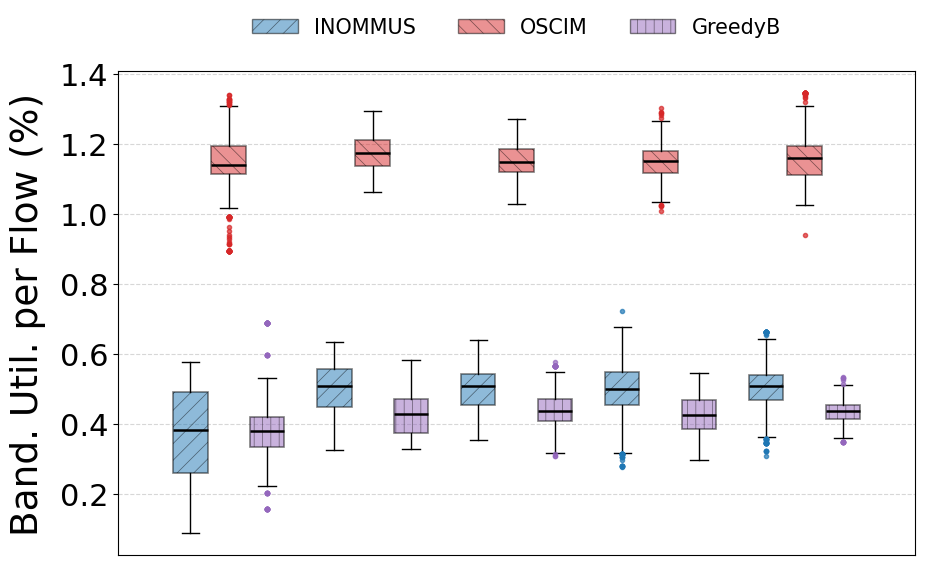

Salvo: boxplot_Power_Co_W_per_Flow_clean.pdf


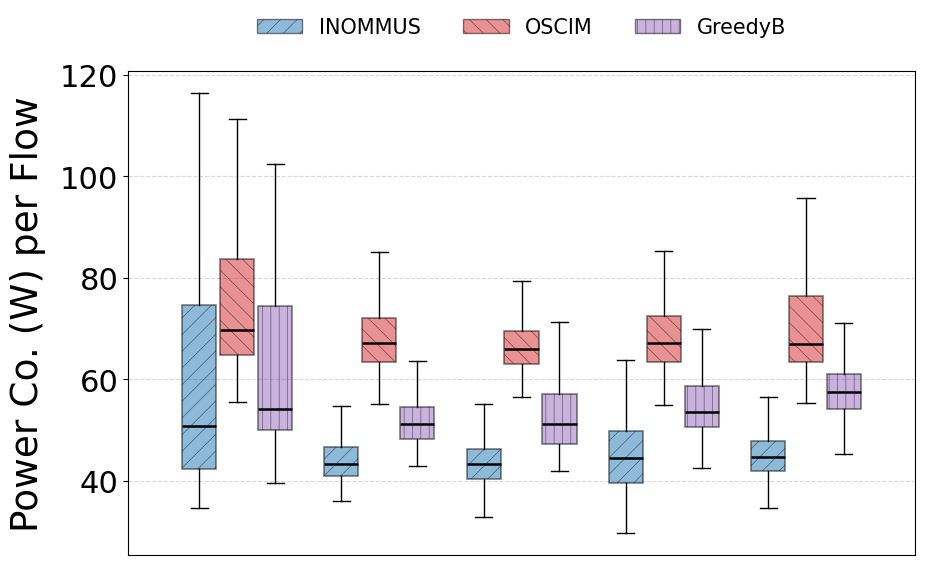

Salvo: boxplot_Power_Co_W_per_Flow_outliers.pdf


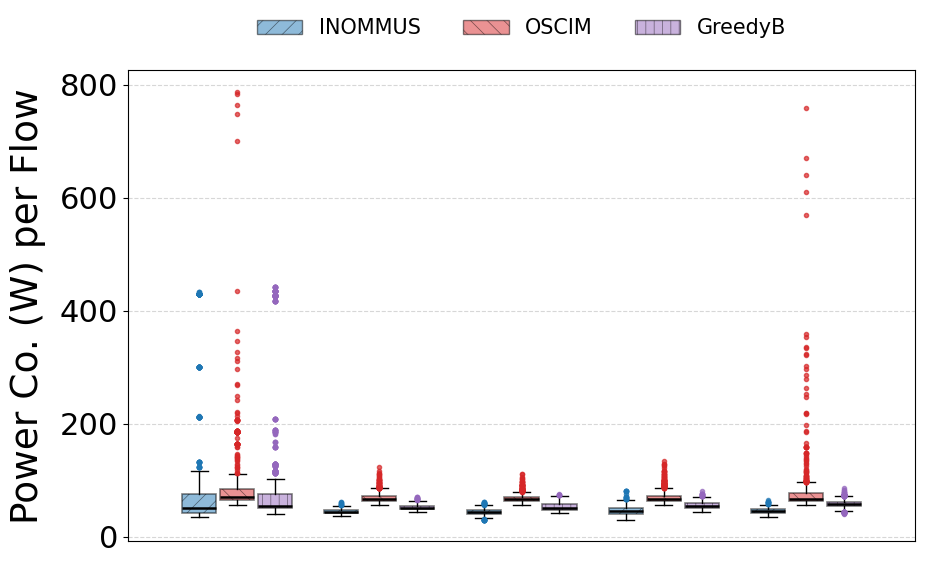

Salvo: boxplot_Service_Lat_Equality_clean.pdf


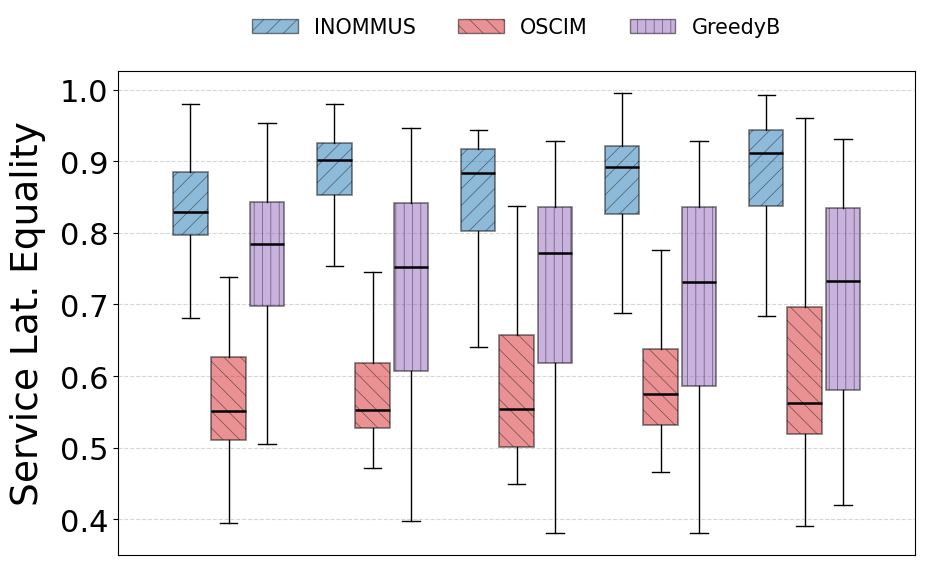

Salvo: boxplot_Service_Lat_Equality_outliers.pdf


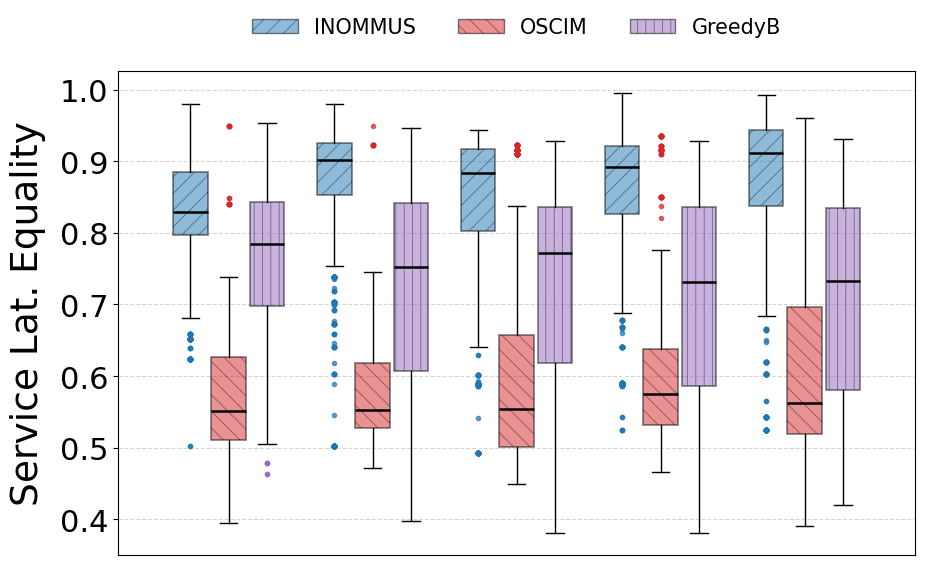

Salvo: boxplot_avg_sfc_reliability_clean.pdf


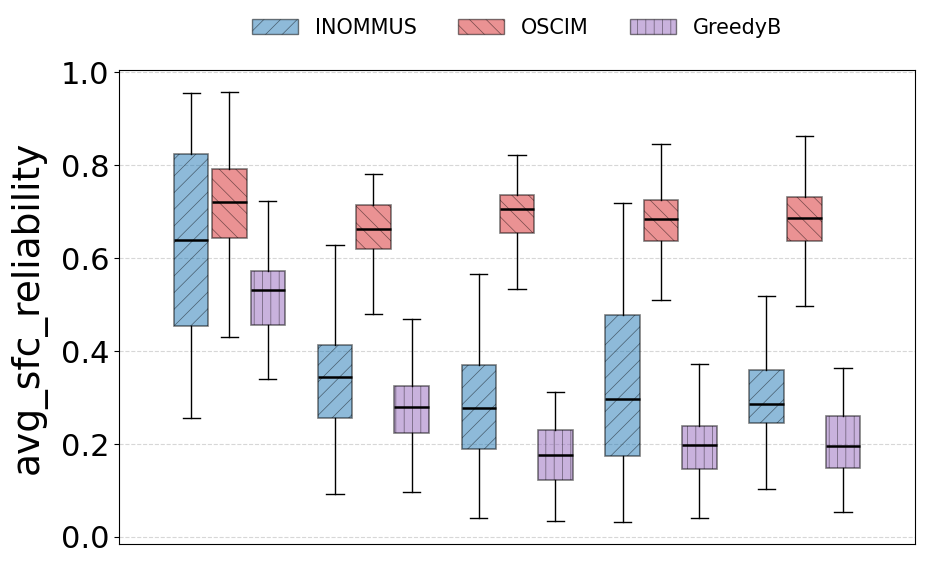

Salvo: boxplot_avg_sfc_reliability_outliers.pdf


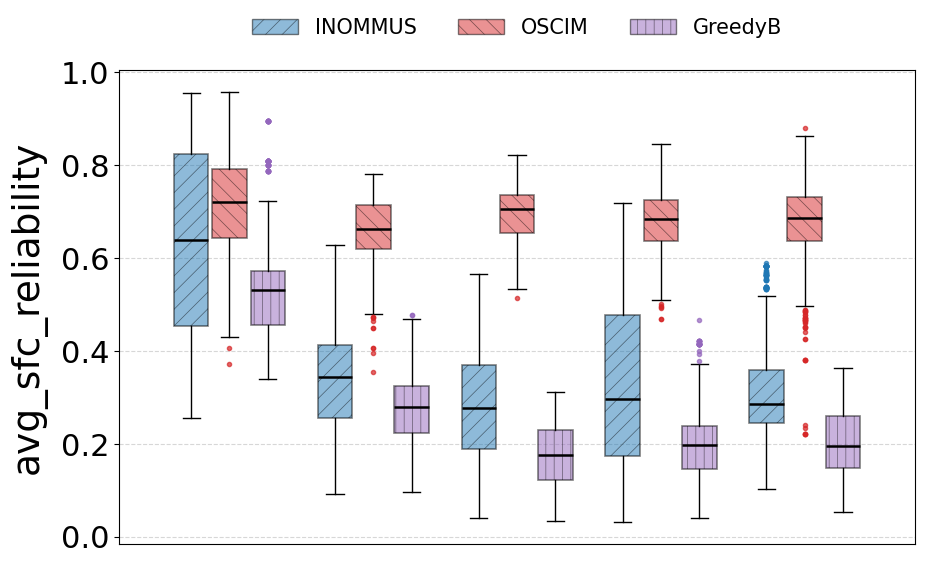

In [7]:
# %% [Célula 7] Execução - Gráficos Temporais

# Seleção de Algoritmos para Plotar
algoritmos_foco = ['INOMMUS', 'DA-RSPPO', 'Hephaestus', 'OSCIM', 'GreedyB']
df_foco = big_data[big_data['algorithm'].isin(algoritmos_foco)].copy()

# Mapeamento Métrica -> Título do Eixo Y
metricas_plot = {
    "Latency (ms)": "latency",
    "Acceptance Ratio (%)": "acceptance_rate",
    "Decision Time (ms)": "decision_time_ms",
    "CPU Util. per Flow (%)": "cpu_per_flow",
    "GPU Util. per Flow (%)": "gpu_per_flow",
    "Band. Util. per Flow (%)": "bandwidth_utilization_per_flow",
    "Power Co. (W) per Flow": "energy_consumption_per_flow",
    "Service Lat. Equality": "jain_fairness_latencia_por_sessao",
    "avg_sfc_reliability": "avg_sfc_reliability",
}

for titulo, col in metricas_plot.items():
    if col not in df_foco.columns:
        print(f"Aviso: Coluna {col} não encontrada.")
        continue
        
    # Multiplicador para porcentagem (se necessário)
    # No ETL já dividimos por 100, então se o título tem %, multiplicamos de volta por 100 para o plot
    fator = 100.0 if "%" in titulo else 1.0
    
    # Criar coluna temporária para plotagem
    col_plot = f"{col}_plot"
    df_foco[col_plot] = df_foco[col] * fator
    
    # Nome do arquivo seguro
    safe_name = re.sub(r"[^\w\-]+", "_", titulo)
    
    # Gerar duas versões: com e sem outliers
    create_boxplot(df_foco, col_plot, titulo, filename=f"boxplot_{safe_name}_clean.pdf", show_outliers=False)
    create_boxplot(df_foco, col_plot, titulo, filename=f"boxplot_{safe_name}_outliers.pdf", show_outliers=True)

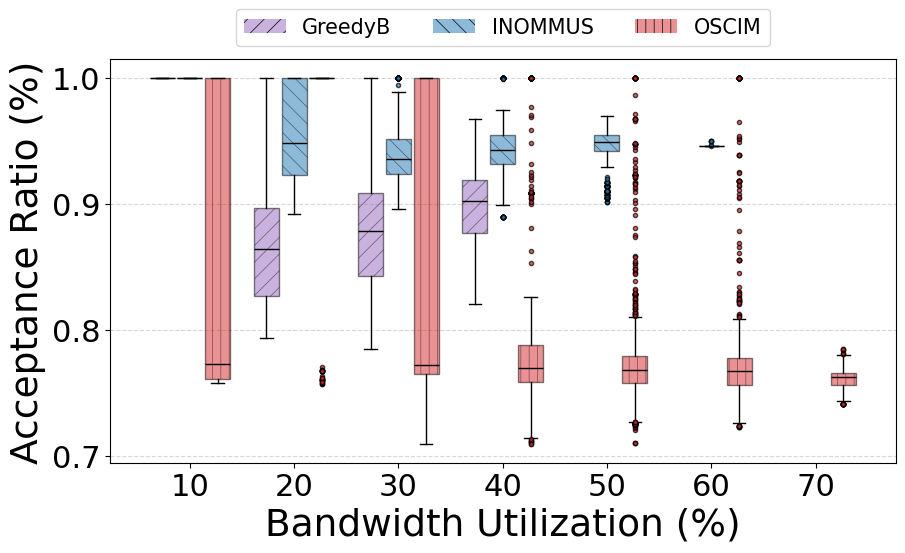

In [8]:
# %% [Célula 8] Execução - Gráfico Binado

create_binned_boxplot(
    df=df_foco,
    x_col='bandwidth_utilization',
    y_col='acceptance_rate', # Já está em decimal no DF, mas a função multiplica por 100 para bin
    x_label='Bandwidth Utilization (%)',
    y_label='Acceptance Ratio (%)',
    bin_size=10,
    filename="binned_acceptance_vs_bw.pdf"
)

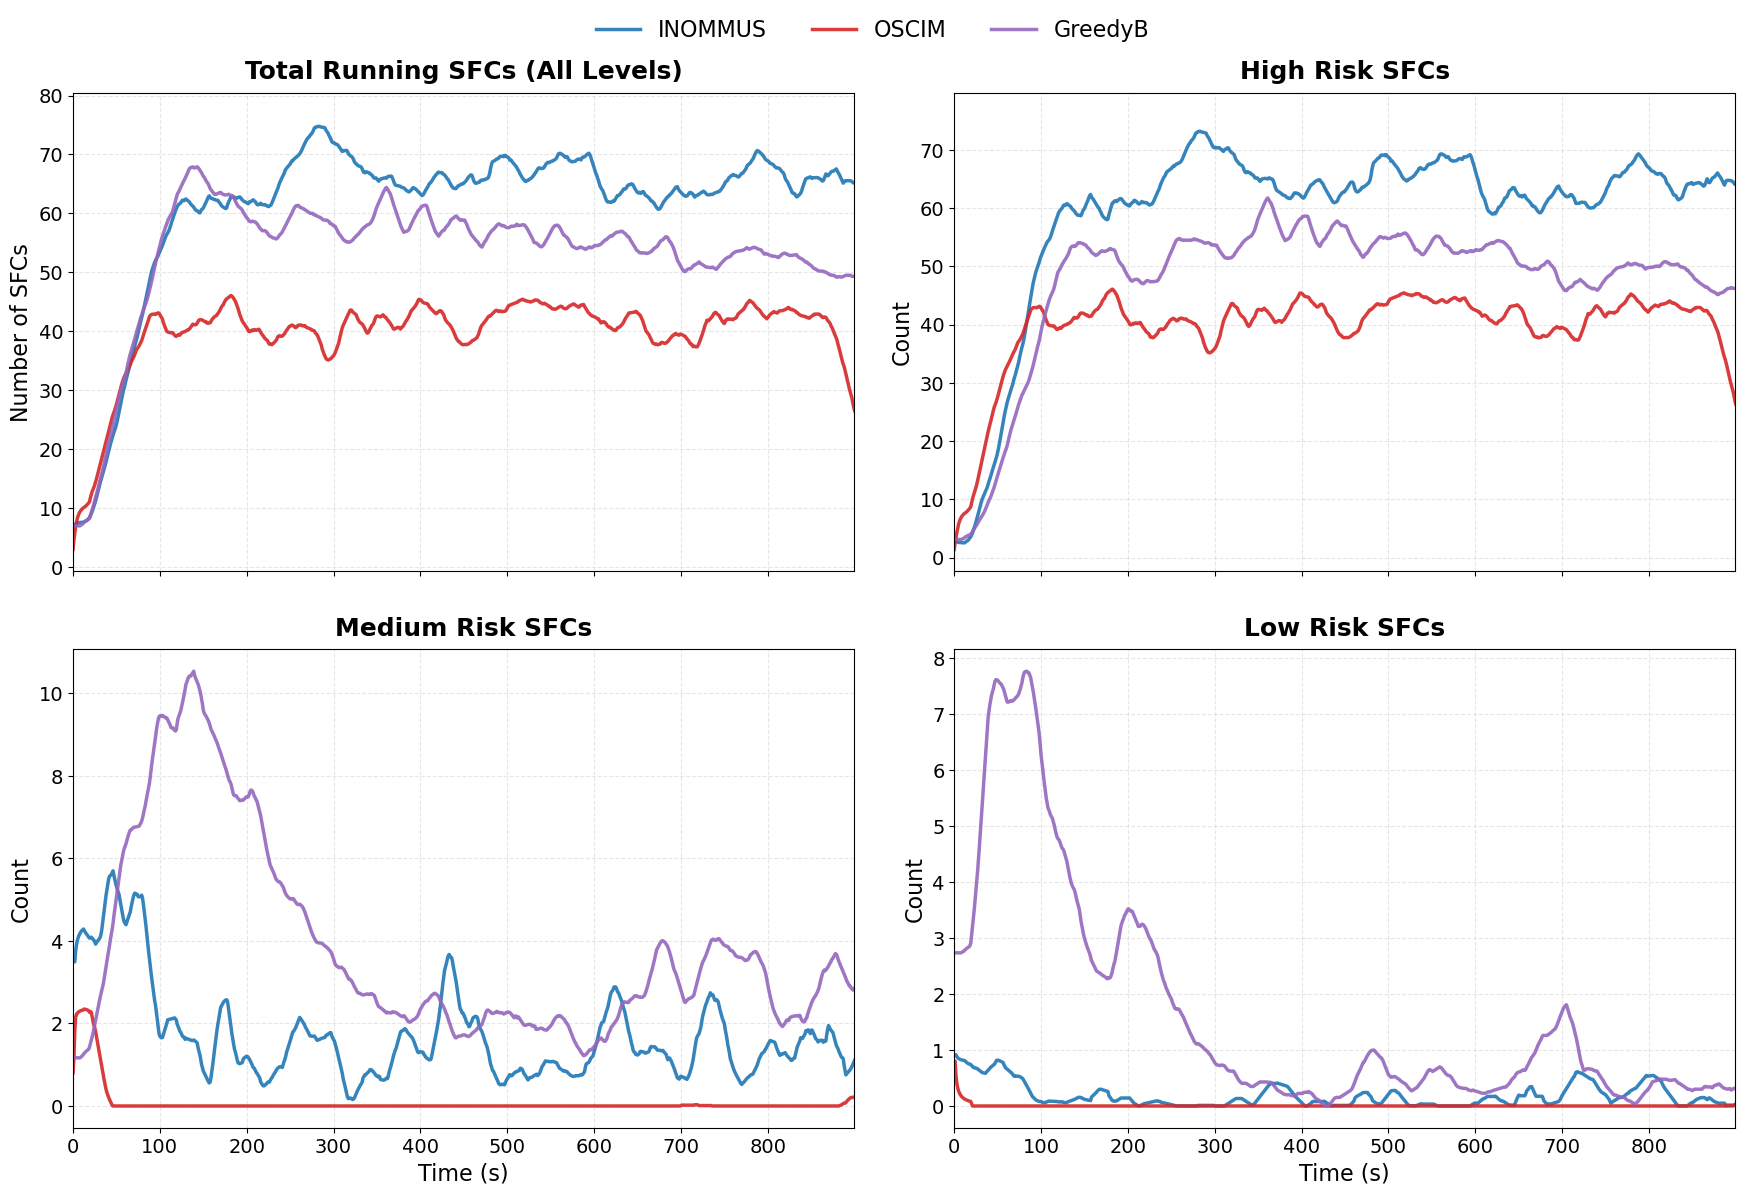

In [9]:
# %% [Célula Atualizada] Dashboard de Risco com Suavização (Rolling Mean)

# ==========================================
# CONFIGURAÇÃO DE SUAVIZAÇÃO
# ==========================================
# Define quantos segundos de dados são usados para calcular a média.
# Valor maior = linha mais lisa (mas pode esconder picos rápidos).
# Valor menor = linha mais detalhada (mas mais tremida).
JANELA_SUAVIZACAO = 20
# ==========================================

def plot_risk_dashboard_suavizado(df, janela=20):
    # Configuração do painel 2x2
    fig, axs = plt.subplots(2, 2, figsize=(18, 12), sharex=True)
    
    plots_config = [
        {
            "ax": axs[0, 0],
            "col": "running_sfcs",
            "title": "Total Running SFCs (All Levels)",
            "ylabel": "Number of SFCs"
        },
        {
            "ax": axs[0, 1],
            "col": "high_risk_sfcs",
            "title": "High Risk SFCs",
            "ylabel": "Count"
        },
        {
            "ax": axs[1, 0],
            "col": "medium_risk_sfcs",
            "title": "Medium Risk SFCs",
            "ylabel": "Count"
        },
        {
            "ax": axs[1, 1],
            "col": "low_risk_sfcs",
            "title": "Low Risk SFCs",
            "ylabel": "Count"
        }
    ]

    # Ordenar algoritmos para consistência na legenda
    algoritmos = sorted(df['algorithm'].unique(), 
                        key=lambda x: list(CORES_ALGORITMOS.keys()).index(x) if x in CORES_ALGORITMOS else 999)

    for config in plots_config:
        ax = config["ax"]
        col = config["col"]
        
        for alg in algoritmos:
            df_alg = df[df['algorithm'] == alg]
            if df_alg.empty: continue
            
            # 1. Agrupar dados brutos por tempo
            series_raw = df_alg.groupby('tempo')[col].mean()
            
            # 2. APLICAR SUAVIZAÇÃO (ROLLING MEAN)
            # min_periods=1 garante que não fiquem buracos no começo do gráfico
            if janela > 1:
                series_plot = series_raw.rolling(window=janela, min_periods=1).mean()
            else:
                series_plot = series_raw
            
            color = CORES_ALGORITMOS.get(alg, 'gray')
            
            # Plotar linha suavizada
            # Aumentei o linewidth para 2.5 para ficar mais bonito
            ax.plot(series_plot.index, series_plot.values, label=alg, color=color, linewidth=2.5, alpha=0.9)

        # Estilização
        ax.set_xlim(series_plot.index.min(), series_plot.index.max()*0.9)
        ax.set_title(config["title"], pad=10, fontweight='bold', fontsize=18)
        ax.set_ylabel(config["ylabel"], fontsize=16)
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.tick_params(axis='both', which='major', labelsize=14)
        
        if config["ax"] in axs[1, :]:
            ax.set_xlabel("Time (s)", fontsize=16)

    # Legenda global
    handles, labels = axs[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), 
               ncol=len(algoritmos), frameon=False, fontsize=16)

    plt.tight_layout()
    plt.savefig(f"risk_dashboard_smooth_{janela}.pdf", dpi=300, bbox_inches='tight')
    plt.show()

# Executar
if 'df_risco' in locals() and not df_risco.empty:
    plot_risk_dashboard_suavizado(df_risco, janela=JANELA_SUAVIZACAO)
else:
    # Caso você tenha reiniciado o kernel, recarrega o df_risco
    # Certifique-se que big_data está carregado
    df_risco = big_data[big_data['tempo'] >= 0].copy()
    plot_risk_dashboard_suavizado(df_risco, janela=JANELA_SUAVIZACAO)

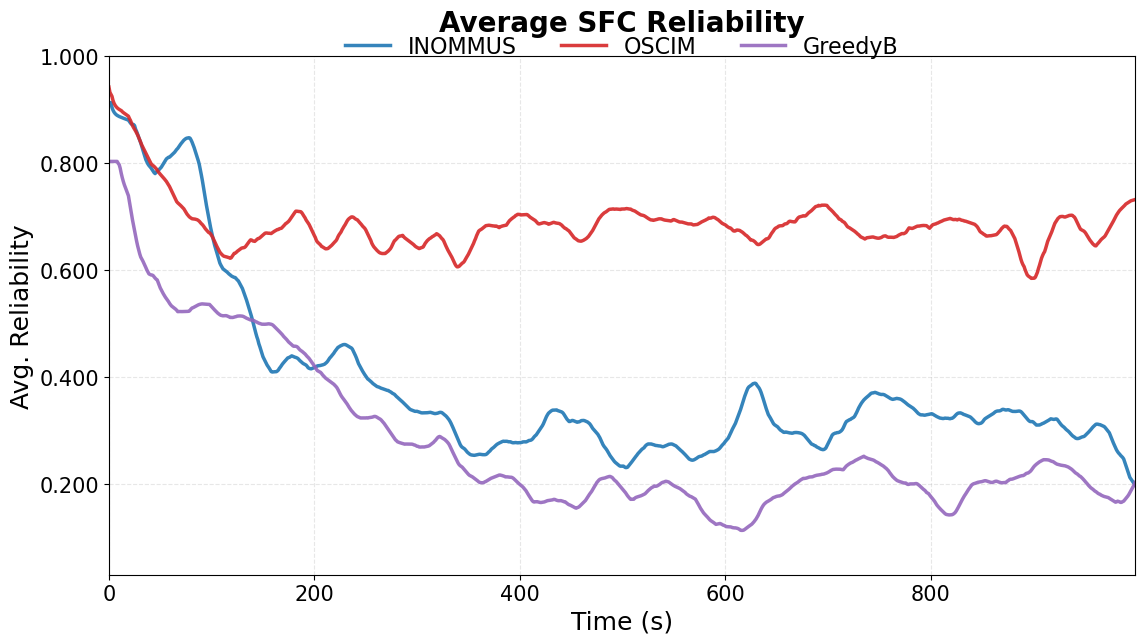

In [10]:
# %% [Célula de Ajuste Fino] Gráfico de Confiabilidade (Título Limpo)

def plot_reliability_final(df, janela=20):
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Ordenação dos algoritmos
    algoritmos = sorted(
        df['algorithm'].unique(), 
        key=lambda x: list(CORES_ALGORITMOS.keys()).index(x) if x in CORES_ALGORITMOS else 999
    )

    min_val_global = 1.0
    max_val_global = 0.0

    for alg in algoritmos:
        df_alg = df[df['algorithm'] == alg]
        if df_alg.empty:
            continue
        
        series_raw = df_alg.groupby('tempo')['avg_sfc_reliability'].mean()
        
        if janela > 1:
            series_plot = series_raw.rolling(window=janela, min_periods=1).mean()
        else:
            series_plot = series_raw
            
        min_val_global = min(min_val_global, series_plot.min())
        max_val_global = max(max_val_global, series_plot.max())
        
        color = CORES_ALGORITMOS.get(alg, 'gray')
        ax.plot(
            series_plot.index,
            series_plot.values,
            label=alg,
            color=color,
            linewidth=2.5,
            alpha=0.9
        )

    # --- TÍTULO E LEGENDAS (CORRIGIDO) ---
    ax.set_xlim(series_plot.index.min(), series_plot.index.max())
    ax.set_title("Average SFC Reliability", pad=18, fontweight='bold', fontsize=20)
    ax.set_ylabel("Avg. Reliability", fontsize=18)
    ax.set_xlabel("Time (s)", fontsize=18)
    
    # Legenda ajustada para não colidir com o título
    ax.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, 1.08),
        ncol=len(algoritmos),
        frameon=False,
        fontsize=16
    )

    margin = (max_val_global - min_val_global) * 0.1
    y_lower = max(0, min_val_global - margin)
    y_upper = min(1.0005, max_val_global + margin)
    ax.set_ylim(y_lower, y_upper)

    from matplotlib.ticker import FormatStrFormatter
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))

    ax.grid(True, linestyle='--', alpha=0.3)
    ax.tick_params(axis='both', labelsize=15)
    
    plt.tight_layout()
    plt.savefig("avg_reliability_final.pdf", dpi=300, bbox_inches='tight')
    plt.show()

plot_reliability_final(df_foco, janela=20)

Carregando dados de resiliência...
Pastas encontradas em ../../results/results_resilient/*: 3


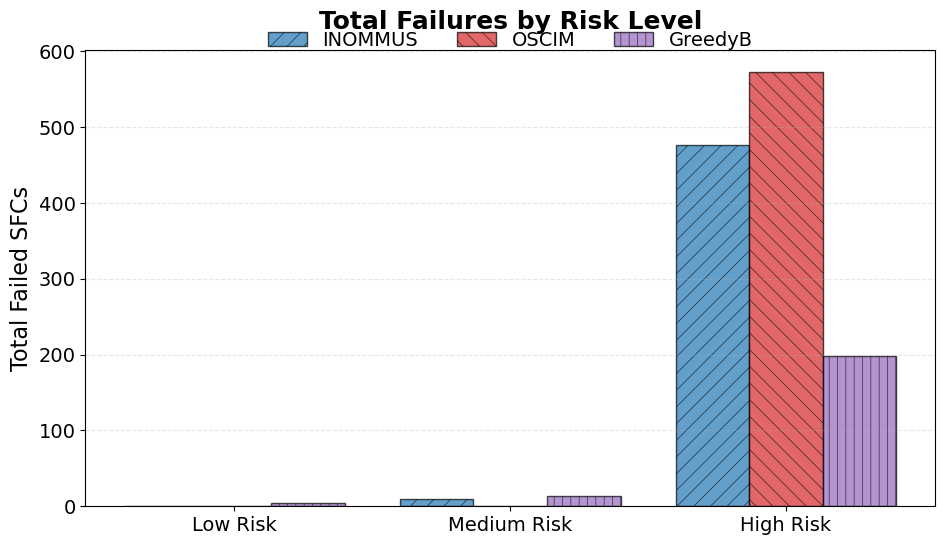

In [11]:
# %% [Célula Nova] Gráfico de Falhas por Nível de Risco (Resiliência)

import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ==========================================
# 1. CONFIGURAÇÃO
# ==========================================
# Caminho para a pasta results_resilient.
# Ajuste o caminho relativo conforme onde seu notebook está salvo.
# Se estiver na raiz: 'results/results_resilient/*'
# Se estiver em subpasta: '../../results/results_resilient/*'
DIR_RESILIENT = '../../results/results_resilient/*' 

# Mapeamento de nomes (igual ao anterior para consistência)
MAPA_NOMES = {
    'ga': 'OSCIM',
    'greedyb': 'GreedyB',
    'kuririn': 'INOMMUS',
    'darsppo': 'DA-RSPPO',
    'hephaestus': 'Hephaestus'
}

# Cores e Hachuras (Estilo consistente)
CORES = {
    "INOMMUS": "#1f77b4",     # Azul
    "DA-RSPPO": "#ff7f0e",    # Laranja
    "Hephaestus": "#2ca02c",  # Verde
    "OSCIM": "#d62728",       # Vermelho
    "GreedyB": "#9467bd",     # Roxo
}
HACHURAS = ['//', '\\\\', '||', '--', '++', 'xx', 'oo', 'OO', '..', '**']

# ==========================================
# 2. PROCESSAMENTO DOS DADOS
# ==========================================
def carregar_dados_resiliencia(diretorio_pattern):
    # {Algoritmo: {'Low': [], 'Medium': [], 'High': []}}
    dados_agrupados = {}
    
    pastas = glob.glob(diretorio_pattern)
    print(f"Pastas encontradas em {diretorio_pattern}: {len(pastas)}")
    
    for pasta in pastas:
        nome_pasta = os.path.basename(os.path.normpath(pasta))
        prefixo = nome_pasta.split('_')[0]
        nome_alg = next((v for k, v in MAPA_NOMES.items() if k in prefixo), prefixo)
        
        if nome_alg not in dados_agrupados:
            dados_agrupados[nome_alg] = {'Low': [], 'Medium': [], 'High': []}
            
        csvs = glob.glob(os.path.join(pasta, "*.csv"))
        for arquivo in csvs:
            try:
                df = pd.read_csv(arquivo)
                if 'low_risk_count' in df.columns:
                    dados_agrupados[nome_alg]['Low'].append(df['low_risk_count'].sum())
                    dados_agrupados[nome_alg]['Medium'].append(df['medium_risk_count'].sum())
                    dados_agrupados[nome_alg]['High'].append(df['high_risk_count'].sum())
            except Exception as e:
                print(f"Erro ao ler {arquivo}: {e}")

    # Calcula a média final
    dados_medios = {}
    for alg, riscos in dados_agrupados.items():
        dados_medios[alg] = {
            risco: (np.mean(valores) if valores else 0)
            for risco, valores in riscos.items()
        }

    return dados_medios


# ==========================================
# 3. PLOTAGEM
# ==========================================
def plot_failures_by_risk(dados):
    if not dados:
        print("Nenhum dado encontrado para plotar.")
        return

    # Categorias e Algoritmos
    categorias = ['Low Risk', 'Medium Risk', 'High Risk']
    mapa_chaves_csv = {'Low Risk': 'Low', 'Medium Risk': 'Medium', 'High Risk': 'High'}
    
    # Ordenar algoritmos (INOMMUS primeiro se existir, ou ordem alfabética)
    algoritmos = sorted(dados.keys(), key=lambda x: list(CORES.keys()).index(x) if x in CORES else 999)
    
    # Configuração do Gráfico
    x = np.arange(len(categorias))
    width = 0.8 / len(algoritmos)  # Largura da barra
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Loop para criar as barras de cada algoritmo
    for i, alg in enumerate(algoritmos):
        # Extrai os valores na ordem: Low, Medium, High
        valores = [dados[alg][mapa_chaves_csv[cat]] for cat in categorias]
        
        posicao = x + (i - len(algoritmos)/2) * width + width/2
        cor = CORES.get(alg, 'gray')
        hachura = HACHURAS[i % len(HACHURAS)]
        
        barras = ax.bar(posicao, valores, width, label=alg, 
                        color=cor, hatch=hachura, edgecolor='black', alpha=0.7)
        
        # Opcional: Adicionar o valor em cima da barra
        # ax.bar_label(barras, padding=3, fmt='%d', fontsize=10)

    # Estilização
    ax.set_ylabel('Total Failed SFCs', fontsize=16)
    ax.set_title('Total Failures by Risk Level', fontsize=18, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(categorias, fontsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Legenda
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.08), 
              ncol=len(algoritmos), frameon=False, fontsize=14)
    
    plt.tight_layout()
    plt.savefig('failures_by_risk_grouped.pdf', dpi=300, bbox_inches='tight')
    plt.show()

# ==========================================
# 4. EXECUÇÃO
# ==========================================
print("Carregando dados de resiliência...")
dados_resiliencia = carregar_dados_resiliencia(DIR_RESILIENT)
plot_failures_by_risk(dados_resiliencia)